# Global Earthquake Activity Analysis and Strong-Event Prediction

This notebook is my end-to-end data science project using a recent global earthquake snapshot from the United States Geological Survey (USGS). The aim is to explore where earthquakes are happening, how magnitude and depth behave, and whether a machine learning model can identify stronger earthquake events from available event features.

Dataset source: [USGS Earthquake Hazards Program - all earthquakes, past month](https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson)

The workflow includes data cleaning, feature engineering, visual analysis, model comparison, hyperparameter tuning, and saving the best model.


## 1. Imports and Project Setup

I keep the setup compact and reproducible. The notebook reads from the saved CSV snapshot in the `data` folder so the analysis can be rerun even if the live API changes later.


In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")

DATA_PATH = Path("data/usgs_earthquakes_all_month.csv")
OUTPUT_DIR = Path("outputs")
MODEL_DIR = Path("models")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42


## 2. Load and Understand the Data

The dataset contains earthquakes reported by USGS over the past month. Each row is one event, with location, magnitude, depth, reporting network, event status, and other USGS event metadata.


In [2]:
df = pd.read_csv(DATA_PATH)
df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
df["updated"] = pd.to_datetime(df["updated"], utc=True, errors="coerce")

print("Rows and columns:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include="all").T)


Rows and columns: (10699, 20)


,id,time,updated,place,magnitude,magnitude_type,longitude,latitude,depth_km,felt,cdi,mmi,alert,status,tsunami,sig,net,type,title,url
0,ci41287263,2026-07-05 11:38:07.480000+00:00,2026-07-05 11:40:12.212000+00:00,"18 km WSW of Johannesburg, CA",1.954872,ml,-117.806168,35.298332,6.93,NaN,NaN,NaN,NaN,automatic,0,59,ci,earthquake,"M 2.0 - 18 km WSW of Johannesburg, CA",https://earthquake.usgs.gov/earthquakes/eventp...
1,nc75389966,2026-07-05 11:37:49.710000+00:00,2026-07-05 11:39:27.241000+00:00,"5 km WNW of Cobb, CA",1.170000,md,-122.781670,38.837334,2.07,NaN,NaN,NaN,NaN,automatic,0,21,nc,earthquake,"M 1.2 - 5 km WNW of Cobb, CA",https://earthquake.usgs.gov/earthquakes/eventp...
2,hv74997406,2026-07-05 11:28:19.630000+00:00,2026-07-05 11:31:51.230000+00:00,"12 km SSE of Volcano, Hawaii",1.720000,md,-155.172836,19.350166,4.60,NaN,NaN,NaN,NaN,automatic,0,46,hv,earthquake,"M 1.7 - 12 km SSE of Volcano, Hawaii",https://earthquake.usgs.gov/earthquakes/eventp...
3,nc75389961,2026-07-05 11:27:09.120000+00:00,2026-07-05 11:28:46.773000+00:00,"5 km NW of The Geysers, CA",0.740000,md,-122.794830,38.806168,3.26,NaN,NaN,NaN,NaN,automatic,0,8,nc,earthquake,"M 0.7 - 5 km NW of The Geysers, CA",https://earthquake.usgs.gov/earthquakes/eventp...
4,nc75389956,2026-07-05 11:26:32.640000+00:00,2026-07-05 11:28:07.167000+00:00,"10 km NE of San Martin, CA",1.170000,md,-121.524834,37.139168,8.95,NaN,NaN,NaN,NaN,automatic,0,21,nc,earthquake,"M 1.2 - 10 km NE of San Martin, CA",https://earthquake.usgs.gov/earthquakes/eventp...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10699 entries, 0 to 10698
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   id              10699 non-null  object             
 1   time            10625 non-null  datetime64[ns, UTC]
 2   updated         10664 non-null  datetime64[ns, UTC]
 3   place           10699 non-null  object             
 4   magnitude       10696 non-null  float64            
 5   magnitude_type  10696 non-null  object             
 6   longitude       10699 non-null  float64            
 7   latitude        10699 non-null  float64            
 8   depth_km        10699 non-null  float64            
 9   felt            503 non-null    float64            
 10  cdi             503 non-null    float64            
 11  mmi             207 non-null    float64            
 12  alert           79 non-null     object             
 13  status          10699 non-null 

None

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,10699,10699,ci41287263,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,10625,NaN,NaN,NaN,2026-06-19 06:13:32.731202560+00:00,2026-06-05 11:52:03.630000+00:00,2026-06-11 20:59:06.870000128+00:00,2026-06-18 16:26:32.736000+00:00,2026-06-25 21:17:49.072000+00:00,2026-07-05 11:38:07.480000+00:00,NaN
updated,10664,NaN,NaN,NaN,2026-06-22 07:37:54.919855616+00:00,2026-06-05 12:05:32.811000+00:00,2026-06-16 01:59:01.122499840+00:00,2026-06-23 05:00:12.854500096+00:00,2026-06-29 20:28:44.110749952+00:00,2026-07-05 11:40:12.212000+00:00,NaN
place,10699,5871,"11 km NW of The Geysers, CA",140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
magnitude,10696.0,NaN,NaN,NaN,1.671069,-1.34,0.8,1.43,2.1,7.8,1.286479
magnitude_type,10696,10,ml,6803,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude,10699.0,NaN,NaN,NaN,-108.795484,-179.951,-153.1305,-122.785667,-112.579083,179.9587,78.988826
latitude,10699.0,NaN,NaN,NaN,39.488998,-62.1125,33.371417,38.830166,52.818417,78.4125,17.910952
depth_km,10699.0,NaN,NaN,NaN,21.664439,-3.17,3.5,7.8369,16.7,624.485,48.833496
felt,503.0,NaN,NaN,NaN,50.153082,0.0,1.0,2.0,7.0,5776.0,376.795402


## 3. Cleaning and Feature Engineering

I remove rows without a valid magnitude or location, then create features that are easy to explain:

- hour, weekday, and day of month
- absolute latitude, because distance from the equator can matter geologically
- log-transformed depth, because depth has a long-tailed distribution
- broad geographic quadrant
- a binary target called `is_strong_event`, where magnitude 4.5 and above is treated as stronger


In [3]:
clean = df.copy()
clean = clean.dropna(subset=["magnitude", "latitude", "longitude", "depth_km", "time"])
clean = clean[clean["type"].fillna("earthquake").eq("earthquake")].copy()

clean["hour"] = clean["time"].dt.hour
clean["weekday"] = clean["time"].dt.day_name()
clean["day_of_month"] = clean["time"].dt.day
clean["abs_latitude"] = clean["latitude"].abs()
clean["log_depth_km"] = np.log1p(clean["depth_km"].clip(lower=0))
clean["hemisphere"] = np.where(clean["latitude"] >= 0, "Northern", "Southern")
clean["east_west"] = np.where(clean["longitude"] >= 0, "Eastern", "Western")
clean["geo_quadrant"] = clean["hemisphere"] + " / " + clean["east_west"]
clean["felt"] = clean["felt"].fillna(0)
clean["tsunami"] = clean["tsunami"].fillna(0).astype(int)
clean["status"] = clean["status"].fillna("unknown")
clean["magnitude_type"] = clean["magnitude_type"].fillna("unknown")
clean["net"] = clean["net"].fillna("unknown")
clean["is_strong_event"] = (clean["magnitude"] >= 4.5).astype(int)

print("Clean rows:", clean.shape[0])
print("Strong event share:")
print(clean["is_strong_event"].value_counts(normalize=True).rename("proportion"))
display(clean.head())


Clean rows: 10464
Strong event share:
is_strong_event
0    0.94094
1    0.05906
Name: proportion, dtype: float64


,id,time,updated,place,magnitude,magnitude_type,longitude,latitude,depth_km,felt,...,url,hour,weekday,day_of_month,abs_latitude,log_depth_km,hemisphere,east_west,geo_quadrant,is_strong_event
0,ci41287263,2026-07-05 11:38:07.480000+00:00,2026-07-05 11:40:12.212000+00:00,"18 km WSW of Johannesburg, CA",1.954872,ml,-117.806168,35.298332,6.93,0.0,...,https://earthquake.usgs.gov/earthquakes/eventp...,11,Sunday,5,35.298332,2.070653,Northern,Western,Northern / Western,0
1,nc75389966,2026-07-05 11:37:49.710000+00:00,2026-07-05 11:39:27.241000+00:00,"5 km WNW of Cobb, CA",1.170000,md,-122.781670,38.837334,2.07,0.0,...,https://earthquake.usgs.gov/earthquakes/eventp...,11,Sunday,5,38.837334,1.121678,Northern,Western,Northern / Western,0
2,hv74997406,2026-07-05 11:28:19.630000+00:00,2026-07-05 11:31:51.230000+00:00,"12 km SSE of Volcano, Hawaii",1.720000,md,-155.172836,19.350166,4.60,0.0,...,https://earthquake.usgs.gov/earthquakes/eventp...,11,Sunday,5,19.350166,1.722767,Northern,Western,Northern / Western,0
3,nc75389961,2026-07-05 11:27:09.120000+00:00,2026-07-05 11:28:46.773000+00:00,"5 km NW of The Geysers, CA",0.740000,md,-122.794830,38.806168,3.26,0.0,...,https://earthquake.usgs.gov/earthquakes/eventp...,11,Sunday,5,38.806168,1.449269,Northern,Western,Northern / Western,0
4,nc75389956,2026-07-05 11:26:32.640000+00:00,2026-07-05 11:28:07.167000+00:00,"10 km NE of San Martin, CA",1.170000,md,-121.524834,37.139168,8.95,0.0,...,https://earthquake.usgs.gov/earthquakes/eventp...,11,Sunday,5,37.139168,2.297573,Northern,Western,Northern / Western,0


## 4. Earthquake Activity Overview

These first charts show the main shape of the data: most events are small, depth is unevenly distributed, and stronger events are a smaller but important part of the dataset.


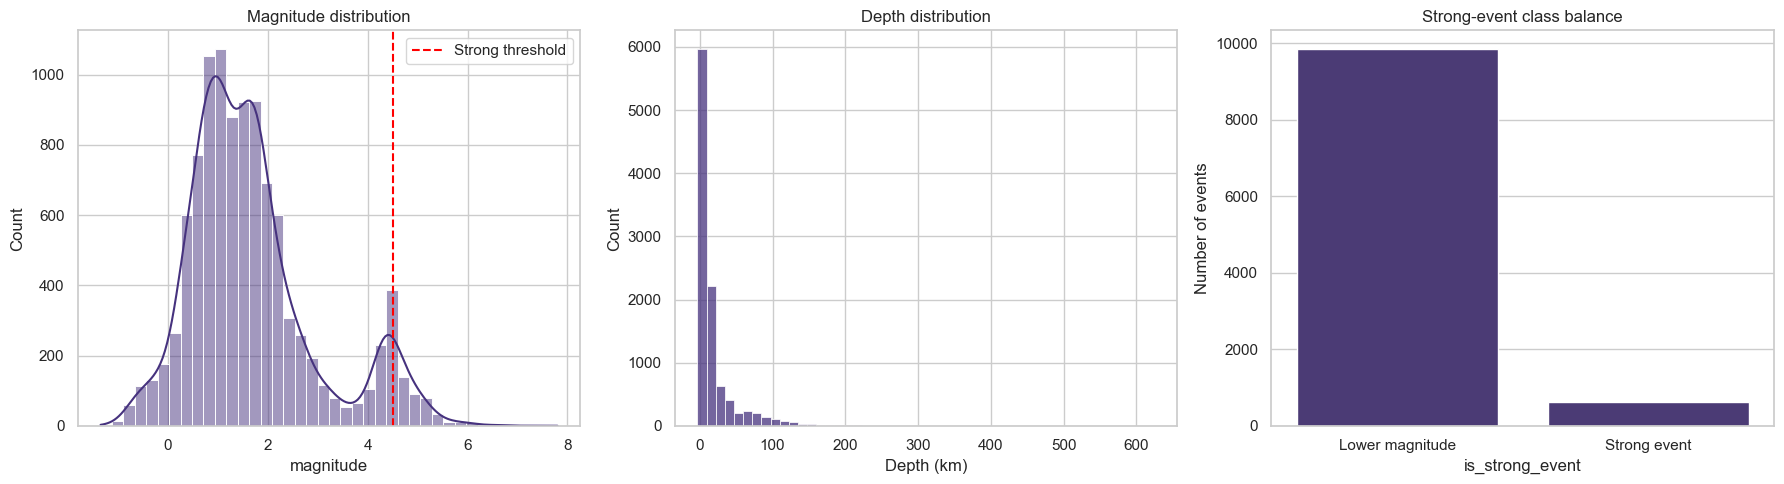

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(clean["magnitude"], bins=40, kde=True, ax=axes[0])
axes[0].axvline(4.5, color="red", linestyle="--", label="Strong threshold")
axes[0].set_title("Magnitude distribution")
axes[0].legend()

sns.histplot(clean["depth_km"], bins=50, ax=axes[1])
axes[1].set_title("Depth distribution")
axes[1].set_xlabel("Depth (km)")

strong_counts = clean["is_strong_event"].map({0: "Lower magnitude", 1: "Strong event"}).value_counts()
sns.barplot(x=strong_counts.index, y=strong_counts.values, ax=axes[2])
axes[2].set_title("Strong-event class balance")
axes[2].set_ylabel("Number of events")

plt.tight_layout()
plt.show()


## 5. Global Location Patterns

This scatter map-style chart uses longitude and latitude to show where the recent earthquakes happened. Larger and warmer points represent stronger magnitudes.


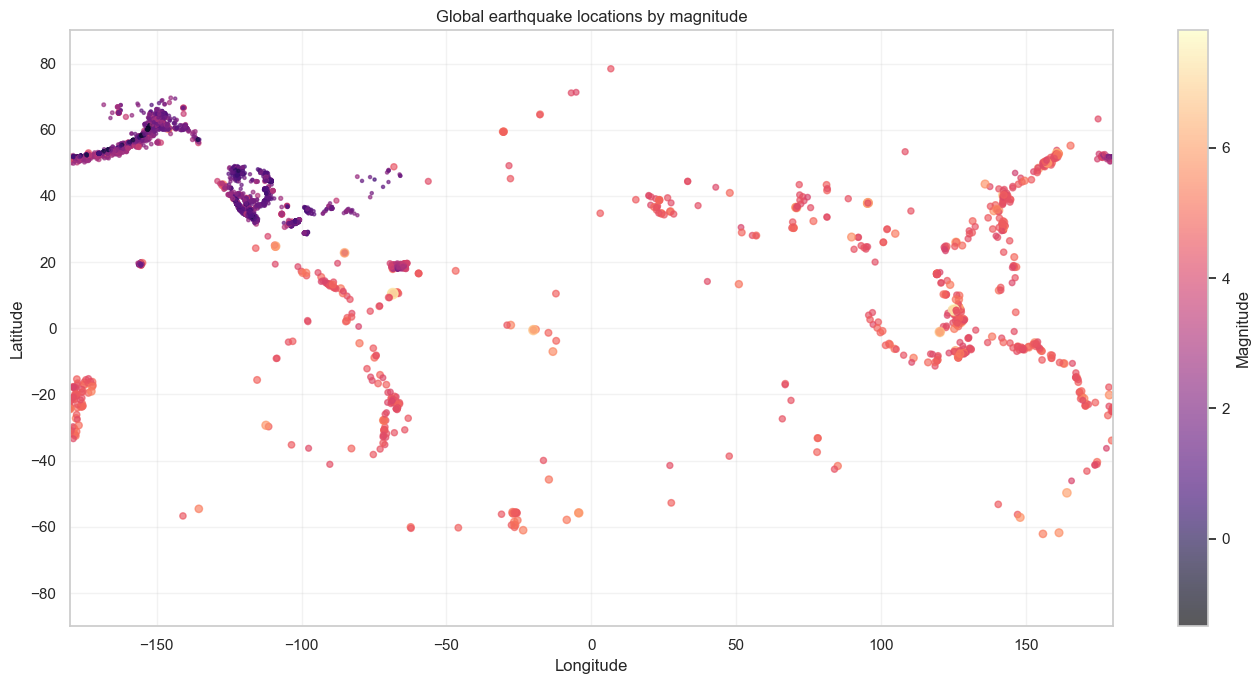

In [5]:
plt.figure(figsize=(14, 7))
scatter = plt.scatter(
    clean["longitude"],
    clean["latitude"],
    c=clean["magnitude"],
    s=np.clip(clean["magnitude"] ** 2, 5, 80),
    cmap="magma",
    alpha=0.65,
)
plt.colorbar(scatter, label="Magnitude")
plt.title("Global earthquake locations by magnitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 6. Time and Region Patterns

I look at activity by weekday, hour, and broad geographic quadrant. This is useful for storytelling and for checking whether the engineered features may carry signal.


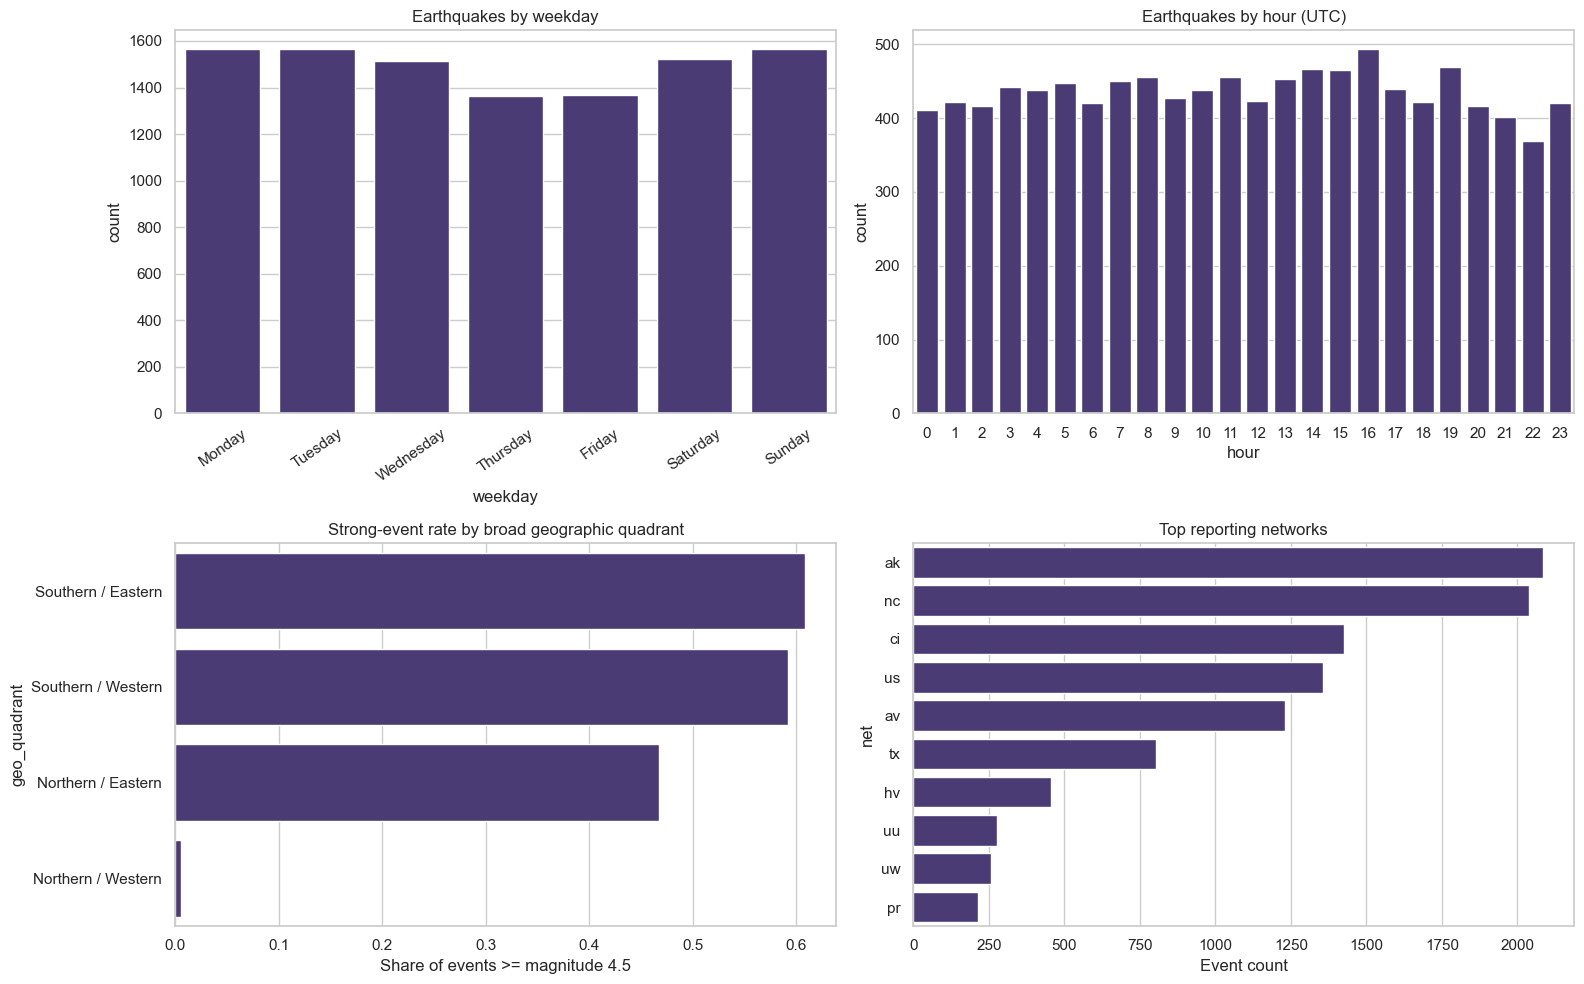

In [6]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=clean, x="weekday", order=weekday_order, ax=axes[0, 0])
axes[0, 0].set_title("Earthquakes by weekday")
axes[0, 0].tick_params(axis="x", rotation=35)

sns.countplot(data=clean, x="hour", ax=axes[0, 1])
axes[0, 1].set_title("Earthquakes by hour (UTC)")

quadrant_rate = clean.groupby("geo_quadrant")["is_strong_event"].mean().sort_values(ascending=False)
sns.barplot(x=quadrant_rate.values, y=quadrant_rate.index, ax=axes[1, 0])
axes[1, 0].set_title("Strong-event rate by broad geographic quadrant")
axes[1, 0].set_xlabel("Share of events >= magnitude 4.5")

top_regions = clean["net"].value_counts().head(10)
sns.barplot(x=top_regions.values, y=top_regions.index, ax=axes[1, 1])
axes[1, 1].set_title("Top reporting networks")
axes[1, 1].set_xlabel("Event count")

plt.tight_layout()
plt.show()


## 7. Relationships Between Magnitude, Depth, and Signal

Magnitude, depth, felt reports, and significance are not independent. I show `sig` in the analysis because it is useful context, but I leave it out of the model because USGS significance is partly derived from magnitude and would leak the answer.


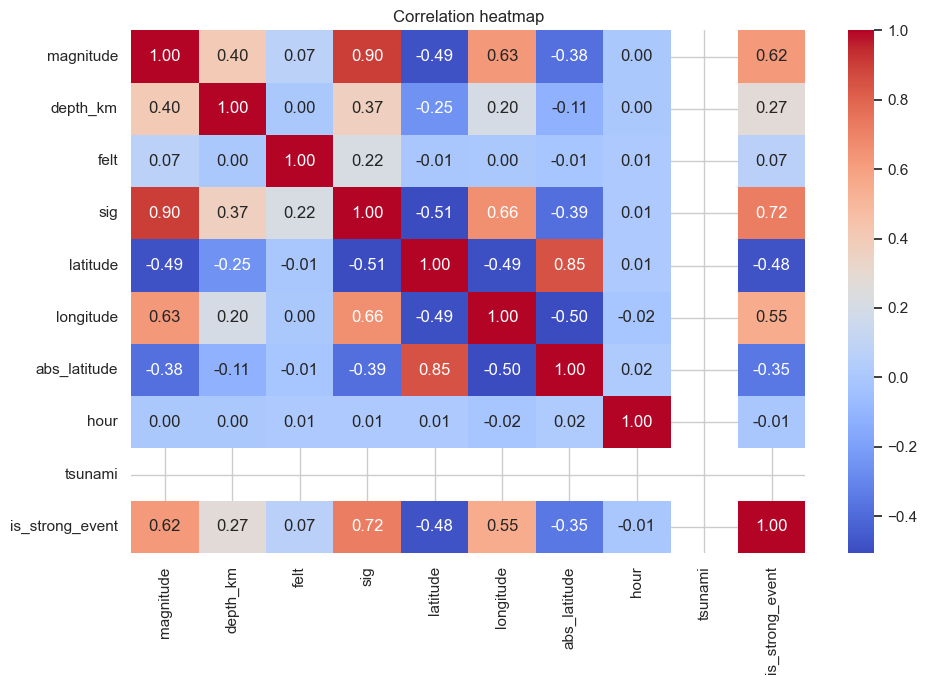

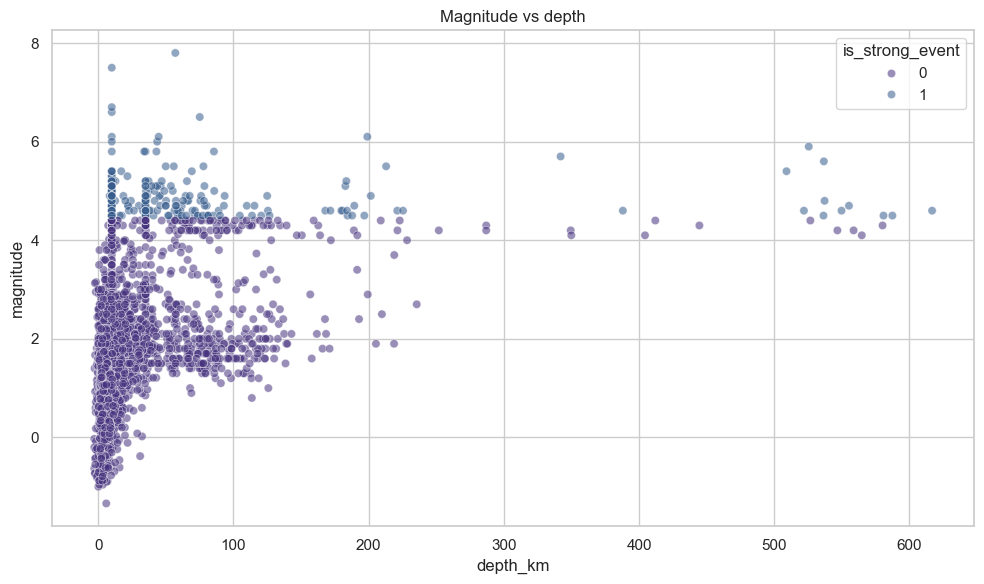

In [7]:
numeric_view = clean[["magnitude", "depth_km", "felt", "sig", "latitude", "longitude", "abs_latitude", "hour", "tsunami", "is_strong_event"]]

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_view.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clean.sample(min(4000, len(clean)), random_state=RANDOM_STATE),
    x="depth_km",
    y="magnitude",
    hue="is_strong_event",
    alpha=0.55,
)
plt.title("Magnitude vs depth")
plt.tight_layout()
plt.show()


## 8. Prepare Machine Learning Data

The target is `is_strong_event`. I avoid using the raw title, URL, exact place text, raw magnitude, and USGS significance score because those would either be unstable text fields or leak the answer. The model uses location, time, depth, and compact event metadata.


In [8]:
feature_columns = [
    "latitude",
    "longitude",
    "depth_km",
    "abs_latitude",
    "log_depth_km",
    "hour",
    "day_of_month",
    "felt",
    "tsunami",
    "magnitude_type",
    "status",
    "net",
    "geo_quadrant",
]

target = "is_strong_event"

X = clean[feature_columns].copy()
y = clean[target].copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [col for col in feature_columns if col not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
    ]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Train shape: (7848, 13)
Test shape: (2616, 13)
Numeric features: ['latitude', 'longitude', 'depth_km', 'abs_latitude', 'log_depth_km', 'hour', 'day_of_month', 'felt', 'tsunami']
Categorical features: ['magnitude_type', 'status', 'net', 'geo_quadrant']


## 9. Train and Compare Baseline Models

I compare four models: Logistic Regression, Random Forest, Extra Trees, and a tuned-style Gradient Boosting alternative from scikit-learn. The goal is to see which family handles this dataset best before tuning.


In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=16, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=400, max_depth=18, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(max_iter=250, learning_rate=0.06, random_state=RANDOM_STATE),
}

fitted_models = {}
rows = []

def predict_score(model, X_values):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_values)[:, 1]
    raw = model.decision_function(X_values)
    return 1 / (1 + np.exp(-raw))

def evaluate(model, X_values, y_true):
    score = predict_score(model, X_values)
    pred = (score >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, score),
        "confusion_matrix": confusion_matrix(y_true, pred).tolist(),
    }

for name, estimator in models.items():
    print(f"Training {name}...")
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    metrics = evaluate(pipe, X_test, y_test)
    fitted_models[name] = pipe
    rows.append({"model": name, **{k: v for k, v in metrics.items() if k != "confusion_matrix"}, "confusion_matrix": metrics["confusion_matrix"]})
    print(metrics)

baseline_results = pd.DataFrame(rows).sort_values(["roc_auc", "f1"], ascending=False)
display(baseline_results)
baseline_results.to_csv(OUTPUT_DIR / "baseline_model_results.csv", index=False)


Training Logistic Regression...
{'accuracy': 0.9518348623853211, 'precision': 0.5503597122302158, 'recall': 0.9935064935064936, 'f1': 0.7083333333333334, 'roc_auc': 0.9858182029181217, 'confusion_matrix': [[2337, 125], [1, 153]]}
Training Random Forest...


{'accuracy': 0.9617737003058104, 'precision': 0.6310679611650486, 'recall': 0.8441558441558441, 'f1': 0.7222222222222222, 'roc_auc': 0.9822153881861437, 'confusion_matrix': [[2386, 76], [24, 130]]}
Training Extra Trees...


{'accuracy': 0.9617737003058104, 'precision': 0.6336633663366337, 'recall': 0.8311688311688312, 'f1': 0.7191011235955056, 'roc_auc': 0.9830448795720933, 'confusion_matrix': [[2388, 74], [26, 128]]}
Training Hist Gradient Boosting...


{'accuracy': 0.963302752293578, 'precision': 0.6986301369863014, 'recall': 0.6623376623376623, 'f1': 0.68, 'roc_auc': 0.9807924609914862, 'confusion_matrix': [[2418, 44], [52, 102]]}


,model,accuracy,precision,recall,f1,roc_auc,confusion_matrix
0,Logistic Regression,0.951835,0.550360,0.993506,0.708333,0.985818,"[[2337, 125], [1, 153]]"
2,Extra Trees,0.961774,0.633663,0.831169,0.719101,0.983045,"[[2388, 74], [26, 128]]"
1,Random Forest,0.961774,0.631068,0.844156,0.722222,0.982215,"[[2386, 76], [24, 130]]"
3,Hist Gradient Boosting,0.963303,0.698630,0.662338,0.680000,0.980792,"[[2418, 44], [52, 102]]"


## 10. Visual Model Comparison

This chart makes it easier to compare model tradeoffs. For this project, ROC-AUC is the main ranking metric because the stronger-event class is smaller than the lower-magnitude class.


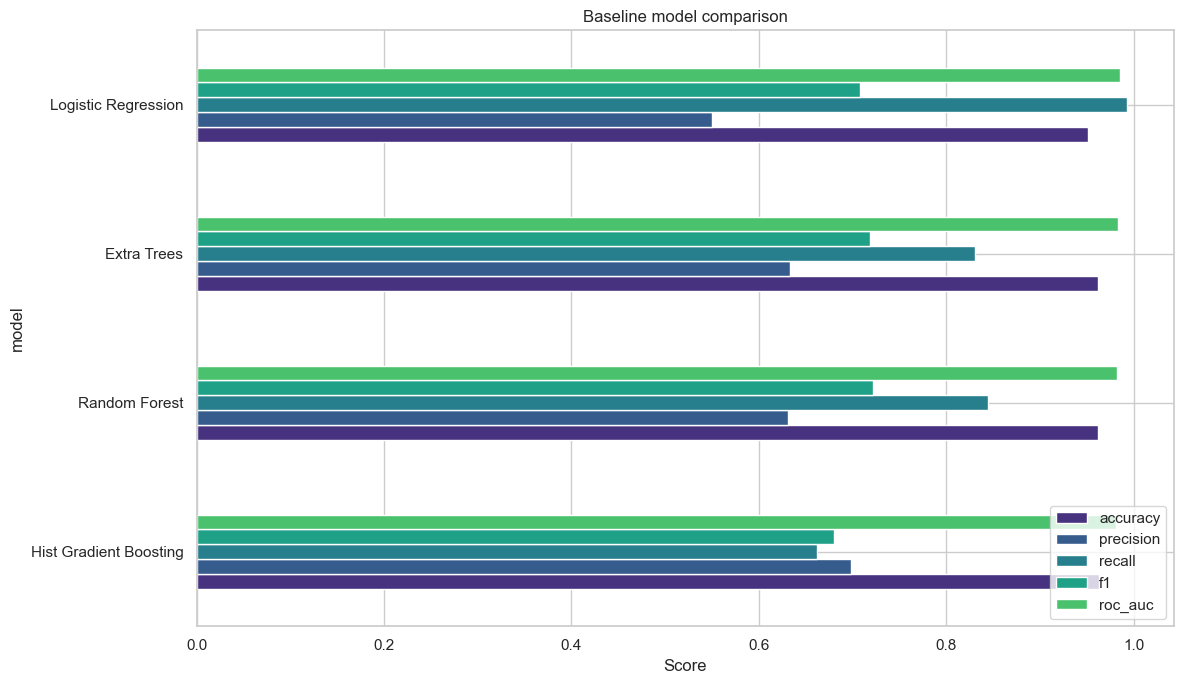

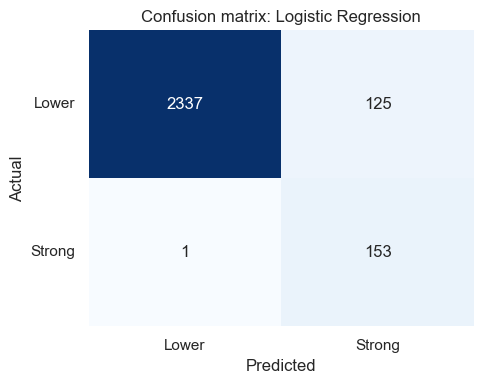

In [10]:
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]

ax = baseline_results.set_index("model")[metric_cols].sort_values("roc_auc").plot(kind="barh", figsize=(12, 7))
ax.set_title("Baseline model comparison")
ax.set_xlabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_baseline_name = baseline_results.iloc[0]["model"]
best_baseline = fitted_models[best_baseline_name]

cm = np.array(baseline_results.iloc[0]["confusion_matrix"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion matrix: {best_baseline_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0.5, 1.5], ["Lower", "Strong"])
plt.yticks([0.5, 1.5], ["Lower", "Strong"], rotation=0)
plt.tight_layout()
plt.show()


## 11. Tune the Best Model Family

I tune the best-performing baseline model with randomized search. This keeps the search practical while still exploring a useful range of settings.


In [11]:
best_name = baseline_results.iloc[0]["model"]
print("Best baseline model:", best_name)

if best_name == "Extra Trees":
    estimator = ExtraTreesClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    param_space = {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [10, 16, 22, None],
        "model__min_samples_leaf": [1, 3, 5, 10],
        "model__max_features": ["sqrt", None],
    }
elif best_name == "Random Forest":
    estimator = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
    param_space = {
        "model__n_estimators": [250, 400, 600],
        "model__max_depth": [10, 16, 22, None],
        "model__min_samples_leaf": [1, 3, 5, 10],
        "model__max_features": ["sqrt", None],
    }
elif best_name == "Hist Gradient Boosting":
    estimator = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
    param_space = {
        "model__max_iter": [150, 250, 350],
        "model__learning_rate": [0.03, 0.06, 0.1],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__l2_regularization": [0.0, 0.1, 1.0],
    }
else:
    estimator = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    param_space = {"model__C": np.logspace(-2, 2, 9)}

tuning_pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])

search = RandomizedSearchCV(
    tuning_pipe,
    param_distributions=param_space,
    n_iter=min(12, np.prod([len(v) for v in param_space.values()])),
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

search.fit(X_train, y_train)
tuned_model = search.best_estimator_
tuned_metrics = evaluate(tuned_model, X_test, y_test)

print("Best parameters:")
print(search.best_params_)
print("Tuned metrics:")
print(tuned_metrics)

tuned_results = pd.DataFrame([{"model": best_name, "best_cv_roc_auc": search.best_score_, "best_params": search.best_params_, **{k: v for k, v in tuned_metrics.items() if k != "confusion_matrix"}, "confusion_matrix": tuned_metrics["confusion_matrix"]}])
display(tuned_results)
tuned_results.to_csv(OUTPUT_DIR / "tuned_model_results.csv", index=False)


Best baseline model: Logistic Regression
Fitting 3 folds for each of 9 candidates, totalling 27 fits


Best parameters:
{'model__C': np.float64(1.0)}
Tuned metrics:
{'accuracy': 0.9518348623853211, 'precision': 0.5503597122302158, 'recall': 0.9935064935064936, 'f1': 0.7083333333333334, 'roc_auc': 0.9858182029181217, 'confusion_matrix': [[2337, 125], [1, 153]]}


,model,best_cv_roc_auc,best_params,accuracy,precision,recall,f1,roc_auc,confusion_matrix
0,Logistic Regression,0.982313,{'model__C': 1.0},0.951835,0.55036,0.993506,0.708333,0.985818,"[[2337, 125], [1, 153]]"


## 12. Feature Importance

If the final model exposes feature importance or coefficients, I use that to understand what drove the predictions. This is not causal proof, but it gives a useful model-level explanation.


,feature,coefficient,absolute_importance
17,cat__magnitude_type_mww,4.360571,4.360571
11,cat__magnitude_type_md,-3.846544,3.846544
13,cat__magnitude_type_ml,-2.576029,2.576029
29,cat__net_pr,2.248016,2.248016
32,cat__net_us,2.177722,2.177722
9,cat__magnitude_type_mb,1.713610,1.713610
22,cat__net_ci,-1.316085,1.316085
10,cat__magnitude_type_mb_lg,-1.111181,1.111181
31,cat__net_tx,-1.007628,1.007628
21,cat__net_av,-0.975689,0.975689


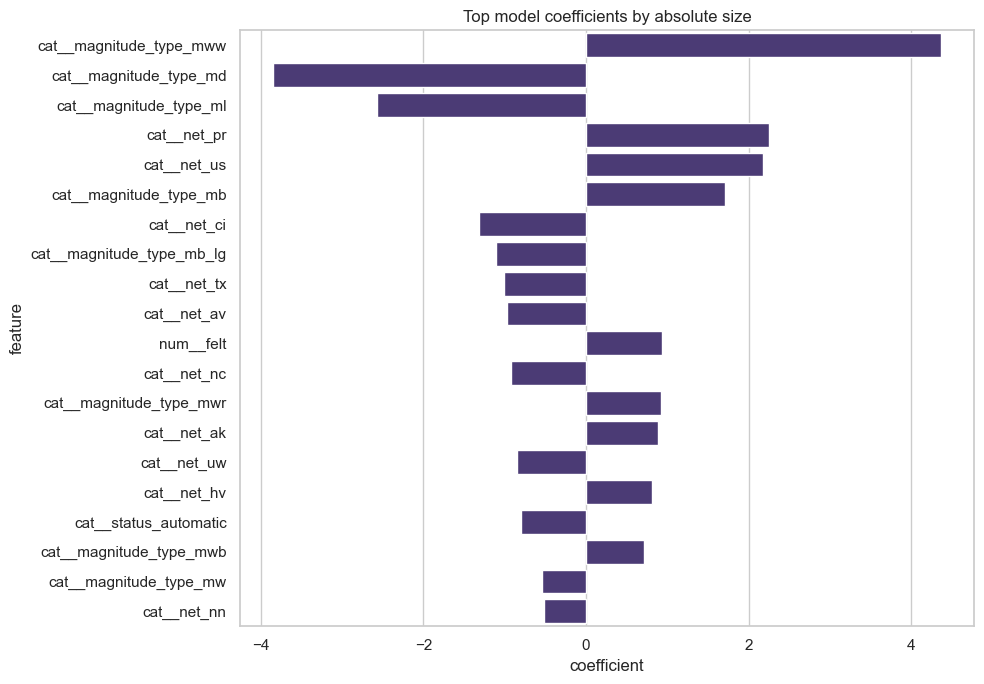

In [12]:
final_model = tuned_model
model_step = final_model.named_steps["model"]
preprocessor_step = final_model.named_steps["preprocess"]

feature_names = preprocessor_step.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    importance_df = pd.DataFrame({"feature": feature_names, "importance": model_step.feature_importances_})
    importance_df["absolute_importance"] = importance_df["importance"].abs()
    title = "Top model features"
elif hasattr(model_step, "coef_"):
    coefficients = model_step.coef_.ravel()
    importance_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    importance_df["absolute_importance"] = importance_df["coefficient"].abs()
    title = "Top model coefficients by absolute size"
else:
    importance_df = pd.DataFrame()
    print("Feature importance is not available for this model.")

if not importance_df.empty:
    importance_df = importance_df.sort_values("absolute_importance", ascending=False).head(20)
    display(importance_df)
    importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

    plt.figure(figsize=(10, 7))
    value_col = "importance" if "importance" in importance_df.columns else "coefficient"
    sns.barplot(data=importance_df, x=value_col, y="feature")
    plt.title(title)
    plt.tight_layout()
    plt.show()


## 13. Save the Final Model

The final tuned pipeline is saved with preprocessing included, so it can accept the original feature columns at prediction time.


In [13]:
model_path = MODEL_DIR / "best_earthquake_strength_model.joblib"
metadata_path = MODEL_DIR / "best_earthquake_strength_model_metadata.json"

joblib.dump(final_model, model_path)

metadata = {
    "dataset_source": "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson",
    "target": target,
    "positive_class": "magnitude >= 4.5",
    "feature_columns": feature_columns,
    "best_model": best_name,
    "best_params": search.best_params_,
    "metrics": tuned_metrics,
    "records_used": int(len(clean)),
}

metadata_path.write_text(json.dumps(metadata, indent=2, default=str), encoding="utf-8")

print(f"Saved model to: {model_path.resolve()}")
print(f"Saved metadata to: {metadata_path.resolve()}")
print(json.dumps(metadata, indent=2, default=str))


Saved model to: C:\Users\edyki\OneDrive\Documents\CodexFolder\earthquake_risk_analysis\models\best_earthquake_strength_model.joblib
Saved metadata to: C:\Users\edyki\OneDrive\Documents\CodexFolder\earthquake_risk_analysis\models\best_earthquake_strength_model_metadata.json
{
  "dataset_source": "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson",
  "target": "is_strong_event",
  "positive_class": "magnitude >= 4.5",
  "feature_columns": [
    "latitude",
    "longitude",
    "depth_km",
    "abs_latitude",
    "log_depth_km",
    "hour",
    "day_of_month",
    "felt",
    "tsunami",
    "magnitude_type",
    "status",
    "net",
    "geo_quadrant"
  ],
  "best_model": "Logistic Regression",
  "best_params": {
    "model__C": 1.0
  },
  "metrics": {
    "accuracy": 0.9518348623853211,
    "precision": 0.5503597122302158,
    "recall": 0.9935064935064936,
    "f1": 0.7083333333333334,
    "roc_auc": 0.9858182029181217,
    "confusion_matrix": [
      [
        